# Rock Muon Study

**Goal.** Quantify the contribution of rock/dirt-origin interactions (neutrino interactions occurring outside the cryostat whose products, mostly muons, reach the active volume and pass our CC1muNp0pi selection), and check how much of that contribution is already counted by the in-time cosmic background estimate taken from off-beam data.

**Why this matters.** Our nominal MC does not simulate interactions occurring in the rock surrounding the detector. If any rock-origin muon fakes our signal topology, it is a background we are not currently modeling. A dedicated rock/dirt sample exists to estimate this, but a slice from that sample can fall into one of several categories, and only some of them represent a *new* background component - the rest are already accounted for elsewhere (e.g., by the off-beam in-time cosmic sample) and must not be double counted.

**Reference.** This follows the structure of Section 6.8.7 ("Rock muon study") in Howard et al.'s CC0pi mesonless technote, adapted to our SPINE/medulla ntuple structure. Their categorization split rock-sample slices into: (1) truth-matched to a neutrino interaction outside the detector, (2) unmatched slices triggered by in-time cosmic activity (already covered by the off-beam sample), (3) unmatched slices triggered by the neutrino interaction where a cosmic slice passed selection (the only non-double-counted, non-negligible piece), and (4) unmatched slices triggered by pre-beam-gate cosmic activity.

**Status of this notebook.** We do not yet know the exact branch names in our ntuple that carry the truth-matching information needed to replicate that categorization (this is different reconstruction/truth-matching machinery than Pandora, since we use SPINE). So this first pass only inspects the file to find the right branches. Nothing past Stage 2 should be trusted until we've confirmed those names.

In [33]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', None)

## Stage 0 - Constants and file access

POT values below are taken from our running exposure bookkeeping (memory/log), not recomputed here. If any of these have changed since the last update, replace them before trusting normalized numbers downstream.

In [34]:
# --- File path ---
FILE_PATH = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'

# --- POT exposures (from our running bookkeeping) ---
POT_ONBEAM = 2.36124e19       # on-beam data POT, 10% Run 2
POT_MC_NOMINAL = 7.178e20     # nominal (neutrino) MC POT, post subrun-failure correction
POT_ROCK = 1.7067e19          # rock/dirt sample POT
ROCK_SCALE = 1.3835           # POT_ONBEAM / POT_ROCK scale factor, applied to rock sample when normalizing to data exposure
OFFBEAM_SCALE = 9.5295e-2     # off-beam (in-time cosmic) scale factor to data exposure

# Sanity check: ROCK_SCALE should equal POT_ONBEAM / POT_ROCK
print(f'POT_ONBEAM / POT_ROCK = {POT_ONBEAM / POT_ROCK:.4f}  (expected ROCK_SCALE = {ROCK_SCALE})')

POT_ONBEAM / POT_ROCK = 1.3835  (expected ROCK_SCALE = 1.3835)


In [35]:
f = uproot.open(FILE_PATH)

# Top-level structure: expect an 'events' directory with a 'full' subdirectory
# containing the 'selected', 'sideband', and 'signal' trees (per our established
# file layout). Print what's actually there instead of assuming.
def list_keys(obj, prefix=''):
    for key in obj.keys(recursive=False):
        full_key = f'{prefix}{key}'
        print(full_key)
        sub = obj[key]
        if hasattr(sub, 'keys'):
            list_keys(sub, prefix=full_key + '/')

list_keys(f)

variations;1
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE_2d;3
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE_2d;2
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE_2d;1
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE_2d;3
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE_2d;2
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE_2d;1
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE_2d;3
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE_2d;2
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE_2d;1
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE_2d;3
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE_2d;2
variations;1/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE_2d;1
var

## Stage 1 - Branch inventory for the `selected` tree

We start with `events/full/selected` since that is where the rock sample was integrated previously (per our systematics TOML setup, `override_category = 11`, `trees=['selected']`). List every branch and its dtype so we can identify: (a) the category/origin branch that flags rock-sample events, and (b) any truth-matching branch that tells us whether a slice's trigger came from the neutrino interaction, in-time cosmic activity, or pre-beam-gate cosmic activity.

**Do not skip this step.** We are not going to guess branch names from the Pandora-based technotes; SPINE's truth-matching machinery is different and may not have a direct analog.

In [36]:
tree = f['events/full/selected']

branch_info = pd.DataFrame({
    'branch': tree.keys(),
    'dtype': [str(tree[b].typename) for b in tree.keys()],
})
branch_info = branch_info.sort_values('branch').reset_index(drop=True)
print(f'Total branches in events/full/selected: {len(branch_info)}')
branch_info

Total branches in events/full/selected: 167


,branch,dtype
0,Evt,int32_t
1,Run,int32_t
2,Subrun,int32_t
3,ppfx_cv_weight,double
4,reco_Q2,double
5,reco_W,double
6,reco_containment_cut,double
7,reco_cut_type,double
8,reco_dalphaT,double
9,reco_dalphaT_deg,double


## Stage 2 - Keyword search for category / truth-matching / cosmic-timing branches

Filter the full branch list above down to plausible candidates. This is a search over branch *names*, not a guess at their meaning - we still need to check the actual values (Stage 3) before using any of them.

In [37]:
keywords = ['categ', 'origin', 'match', 'cosmic', 'flash', 'trigger', 'dirt', 'rock', 'gate', 'time']

for kw in keywords:
    hits = branch_info[branch_info['branch'].str.contains(kw, case=False, na=False)]
    print(f"--- keyword: '{kw}' ({len(hits)} matches) ---")
    if len(hits) > 0:
        print(hits.to_string(index=False))
    print()

--- keyword: 'categ' (1 matches) ---
       branch  dtype
true_category double

--- keyword: 'origin' (0 matches) ---

--- keyword: 'match' (0 matches) ---

--- keyword: 'cosmic' (0 matches) ---

--- keyword: 'flash' (4 matches) ---
               branch  dtype
       reco_flash_cut double
reco_flash_hypothesis double
      reco_flash_time double
  reco_flash_total_pe double

--- keyword: 'trigger' (0 matches) ---

--- keyword: 'dirt' (0 matches) ---

--- keyword: 'rock' (0 matches) ---

--- keyword: 'gate' (0 matches) ---

--- keyword: 'time' (1 matches) ---
         branch  dtype
reco_flash_time double



### Finding from Stage 2 (correction)

The keyword search inside `events/full/selected` returned only `true_category` (categ) and four `reco_flash_*` branches (flash/time). No `origin`, `match`, `cosmic`, `trigger`, or `gate` branch exists there. The `rock` keyword also came back empty from that search - but that was our mistake, not a real absence. That search only ever looked at branch names inside `events/full/selected`. It never looked at the file's other top-level groups, and Stage 0's `list_keys(f)` dump shows there is a separate `events/rock/` group sitting alongside `events/full/`, with its own `POT`, `Livetime`, `selected`, and `sideband` trees. `events/rock/selected` carries the same branch schema as `events/full/selected`, including its own `true_category`.

**Consequence.** The rock sample is not a category value to hunt for inside `full` - it's a standalone, already-selectable, already-POT-normalizable sample. We don't need Stage 3 as originally planned (searching `true_category` for a rock-like value in `full`); we load `events/rock/selected` and `events/rock/sideband` directly, using the file's own `events/rock/POT` for normalization.

**What's still missing.** Howard's four-way double-counting split (matched-to-outside-interaction / cosmic-triggered-already-counted / neutrino-triggered-cosmic-passing / pre-gate-cosmic) still isn't reproducible - `events/rock/selected` has the same branch list as `events/full/selected`, i.e. no `origin`/`match`/`cosmic`-trigger branch. That part of the analysis still needs to go to Justin/Chris.

## Stage 3 - Read the rock sample's own POT and Livetime

`POT` and `Livetime` are stored as trees (not scalars), consistent with `events/full/POT` and `events/full/Livetime`. Read every branch in each and compare against the `POT_ROCK` bookkeeping constant from Stage 0 - if they disagree, the constant is stale and should be updated, not the other way around.

In [38]:
rock_pot_obj = f['events/rock/POT']
rock_livetime_obj = f['events/rock/Livetime']

print('events/rock/POT classname:', rock_pot_obj.classname)
print('events/rock/Livetime classname:', rock_livetime_obj.classname)
print()

def summarize_hist(name, obj):
    values, edges = obj.to_numpy()
    print(f'{name}: {len(values)} bin(s)')
    print(f'  bin contents: {values}')
    print(f'  bin edges: {edges}')
    print(f'  sum of bin contents: {values.sum()}')

summarize_hist('events/rock/POT', rock_pot_obj)
print()
summarize_hist('events/rock/Livetime', rock_livetime_obj)
print()
print(f'Bookkeeping constant POT_ROCK = {POT_ROCK}')
print('Compare the sum above to this constant before trusting any scaled numbers below.')

events/rock/POT classname: TH1D
events/rock/Livetime classname: TH1D

events/rock/POT: 1 bin(s)
  bin contents: [1.70669366e+19]
  bin edges: [0. 1.]
  sum of bin contents: 1.7066936623234548e+19

events/rock/Livetime: 1 bin(s)
  bin contents: [201720.]
  bin edges: [0. 1.]
  sum of bin contents: 201720.0

Bookkeeping constant POT_ROCK = 1.7067e+19
Compare the sum above to this constant before trusting any scaled numbers below.


## Stage 4 - `true_category` inside the rock sample itself

`events/rock/selected` and `events/rock/sideband` each have their own `true_category`. This is not the truth-matching split we need, but it's a useful diagnostic we haven't looked at yet - what SPINE's categorization logic assigned to out-of-cryostat interactions.

In [39]:
for tree_name in ['selected', 'sideband']:
    t = f[f'events/rock/{tree_name}']
    cat_vals = t['true_category'].array(library='np')
    unique, counts = np.unique(cat_vals, return_counts=True)
    counts_df = pd.DataFrame({'true_category': unique, 'n_slices': counts})
    counts_df['fraction'] = counts_df['n_slices'] / counts_df['n_slices'].sum()
    print(f'--- rock/{tree_name} (total = {len(cat_vals)}) ---')
    print(counts_df.to_string(index=False))
    print()

--- rock/selected (total = 12) ---
 true_category  n_slices  fraction
           4.0         4  0.333333
           6.0         2  0.166667
           7.0         2  0.166667
           8.0         1  0.083333
           9.0         3  0.250000

--- rock/sideband (total = 4) ---
 true_category  n_slices  fraction
           7.0         1      0.25
           9.0         3      0.75



## Stage 5 - POT-normalized rock contribution, analogous to Howard's Figure 91

Scale both the rock sample and the neutrino MC (`full`) to the on-beam data exposure, then express the rock sample's scaled count as a fraction of the total (rock + neutrino MC), separately for `selected` and `sideband`. This mirrors the 6.7% (signal) / 1.3-1.8% (kinematic bins) figures Howard reports, but for our selection.

**Caveat, stated plainly:** this is a raw event-rate contribution, not a background estimate with the double-counting correction Howard applied. We still don't know how much of this rock contribution is already covered by the off-beam in-time cosmic sample. Treat this as an upper bound on the missing background, not a final answer.

In [40]:
mc_scale = POT_ONBEAM / POT_MC_NOMINAL
rock_scale_computed = POT_ONBEAM / POT_ROCK  # replace POT_ROCK with the file's own value once Stage 3 confirms it

for tree_name in ['selected', 'sideband']:
    n_full = f[f'events/full/{tree_name}'].num_entries
    n_rock = f[f'events/rock/{tree_name}'].num_entries
    n_full_scaled = n_full * mc_scale
    n_rock_scaled = n_rock * rock_scale_computed
    total_scaled = n_full_scaled + n_rock_scaled
    rock_fraction = n_rock_scaled / total_scaled if total_scaled > 0 else float('nan')
    print(f'--- {tree_name} ---')
    print(f'  full: {n_full} raw -> {n_full_scaled:.1f} scaled to on-beam POT')
    print(f'  rock: {n_rock} raw -> {n_rock_scaled:.1f} scaled to on-beam POT')
    print(f'  rock fraction of (full + rock), POT-normalized: {rock_fraction:.4f} ({rock_fraction*100:.2f}%)')
    print()

--- selected ---
  full: 98983 raw -> 3256.1 scaled to on-beam POT
  rock: 12 raw -> 16.6 scaled to on-beam POT
  rock fraction of (full + rock), POT-normalized: 0.0051 (0.51%)

--- sideband ---
  full: 34420 raw -> 1132.3 scaled to on-beam POT
  rock: 4 raw -> 5.5 scaled to on-beam POT
  rock fraction of (full + rock), POT-normalized: 0.0049 (0.49%)



## Next steps

1. Run Stages 3-5 and report back: the file's own rock POT/Livetime values, the `true_category` breakdown inside `events/rock/selected` and `events/rock/sideband`, and the POT-normalized rock fraction for both trees.
2. If the file's rock POT disagrees with our `POT_ROCK` bookkeeping constant, update the constant (in Stage 0) before trusting any further scaled numbers - flag this explicitly rather than silently averaging or picking one.
3. The double-counting question (how much of the rock contribution is already covered by the off-beam in-time cosmic sample) is still open - this ntuple does not carry the trigger-origin truth information Howard's Pandora-based analysis used. This needs to go to Justin/Chris: either a new branch, or a statement that SPINE's slice-building sidesteps the ambiguity differently.
4. Once fraction numbers are in hand, decide whether this belongs in the technote as a standalone rock-muon subsection (mirroring Howard's 6.8.7) or folded into the existing background/systematics discussion.

## Stage 6 - Locate on-beam/off-beam data before building the plot

Before drawing the POT-normalized comparison figure (the selection-level analog of Howard's Figure 91: full MC by category, rock, and data), we need to know how real data appears in this file. The systematics TOML defines separate `onbeam` and `offbeam` samples (both `ismc = false`), the same way `rock` is a separate sample from `nominal` - so real data may live in its own top-level group the same way `events/rock/` does, rather than being mixed into `events/full/selected` via a flag. Check both possibilities rather than assuming either.

In [41]:
# Possibility 1: separate top-level groups (like events/rock/)
print('Top-level groups under events/:')
for key in f['events'].keys(recursive=False):
    print(' ', key)
print()

# Possibility 2: a data/MC flag mixed into events/full/selected
sel = f['events/full/selected']
is_data_vals = sel['reco_is_data'].array(library='np')
unique, counts = np.unique(is_data_vals, return_counts=True)
print('reco_is_data values in events/full/selected:')
print(dict(zip(unique, counts)))

Top-level groups under events/:
  full;1
  rock;1
  onbeam;1
  offbeam;1

reco_is_data values in events/full/selected:
{np.float64(-5.0): np.int64(98983)}


## Stage 7 - POT-normalized selection-level comparison plot

Analog of Howard's Figure 91: stacked MC by `true_category` (using the corrected mapping from the medulla selection TOML), the rock/dirt sample as its own stacked component, and on-beam data overlaid as points - built from whatever Stage 6 found, not assumed. Variable: `reco_dpT` (note: stored in MeV/c per our conventions, converted to GeV/c here), since that's the primary observable for this analysis.

**This cell has a placeholder for the data overlay** (`DATA_SOURCE`) - set it based on what Stage 6 printed before running. If data lives in a separate `events/onbeam/` group, use that path; if it's a flag inside `events/full/selected`, filter on it instead. Do not guess past what Stage 6 showed.

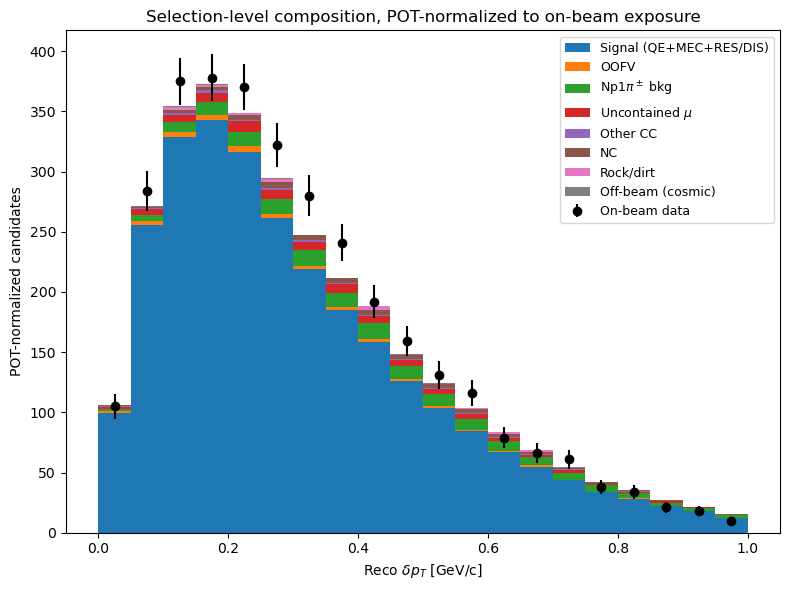

In [42]:
# Stage 6 confirmed: onbeam/offbeam are separate top-level groups (like rock),
# and reco_is_data inside events/full/selected is a constant sentinel (-5.0), not a real flag.
DATA_SOURCE = 'separate_group'

category_groups = {
    'Signal (QE+MEC+RES/DIS)': [0, 1, 2],
    'OOFV':                    [3],
    'Np1$\pi^\pm$ bkg':         [4],
    'Uncontained $\mu$':       [5, 6],
    'Other CC':                [7],
    'NC':                      [8],
}

sel = f['events/full/selected']
true_cat = sel['true_category'].array(library='np')
dpT_mev = sel['reco_dpT'].array(library='np')
dpT_gev = dpT_mev / 1000.0
finite_mask = np.isfinite(dpT_gev)

rock_sel = f['events/rock/selected']
rock_dpT_gev = rock_sel['reco_dpT'].array(library='np') / 1000.0
rock_finite = np.isfinite(rock_dpT_gev)

offbeam_sel = f['events/offbeam/selected']
offbeam_dpT_gev = offbeam_sel['reco_dpT'].array(library='np') / 1000.0
offbeam_finite = np.isfinite(offbeam_dpT_gev)

bins = np.linspace(0, 1.0, 21)  # GeV/c; adjust range once we see the distribution
mc_scale = POT_ONBEAM / POT_MC_NOMINAL
rock_scale_computed = POT_ONBEAM / POT_ROCK

fig, ax = plt.subplots(figsize=(8, 6))

stack_data = []
stack_labels = []
stack_weights = []
for label, cats in category_groups.items():
    mask = finite_mask & np.isin(true_cat, cats)
    stack_data.append(dpT_gev[mask])
    stack_labels.append(label)
    stack_weights.append(np.full(mask.sum(), mc_scale))

stack_data.append(rock_dpT_gev[rock_finite])
stack_labels.append('Rock/dirt')
stack_weights.append(np.full(rock_finite.sum(), rock_scale_computed))

# Off-beam data provides the in-time cosmic prediction, same role as in Howard's Fig. 91
stack_data.append(offbeam_dpT_gev[offbeam_finite])
stack_labels.append('Off-beam (cosmic)')
stack_weights.append(np.full(offbeam_finite.sum(), OFFBEAM_SCALE))

ax.hist(stack_data, bins=bins, weights=stack_weights, stacked=True, label=stack_labels)

if DATA_SOURCE == 'separate_group':
    data_dpT = f['events/onbeam/selected']['reco_dpT'].array(library='np') / 1000.0
    data_finite = np.isfinite(data_dpT)
    data_counts, _ = np.histogram(data_dpT[data_finite], bins=bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    ax.errorbar(bin_centers, data_counts, yerr=np.sqrt(data_counts), fmt='ko', label='On-beam data')
elif DATA_SOURCE == 'flag_in_full':
    data_mask = finite_mask & (is_data_vals == 1)  # confirm the flag value for \"is data\" from Stage 6 output
    data_counts, _ = np.histogram(dpT_gev[data_mask], bins=bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    ax.errorbar(bin_centers, data_counts, yerr=np.sqrt(data_counts), fmt='ko', label='On-beam data')
else:
    print('DATA_SOURCE not set - skipping data overlay. Set it from Stage 6 output before finalizing this plot.')

ax.set_xlabel(r'Reco $\delta p_T$ [GeV/c]')
ax.set_ylabel('POT-normalized candidates')
ax.legend(fontsize=9)
ax.set_title('Selection-level composition, POT-normalized to on-beam exposure')
plt.tight_layout()
plt.show()